# Benchmark: Gators vs Feature-Engine Imputers

This notebook compares the performance of **Gators imputers** (Polars-based) vs **feature-engine imputers** (pandas-based) across different dataset sizes.

**Objective**: Demonstrate Gators' multi-core processing advantages for data imputation tasks.

**Transformers Compared**:
- `gators.imputers.NumericImputer` vs `feature_engine.imputation.MeanMedianImputer`
- `gators.imputers.NumericImputer` (constant) vs `feature_engine.imputation.ArbitraryNumberImputer`
- `gators.imputers.StringImputer` vs `feature_engine.imputation.CategoricalImputer`

**Dataset Sizes**: 1K, 10K, 100K, 1M rows

**Note**: Feature-engine operates on pandas DataFrames, while Gators uses Polars for multi-core parallel processing.

## Setup & Imports

In [27]:
import polars as pl
import pandas as pd
import numpy as np
import time
from typing import Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Gators imputers
from gators.imputers import NumericImputer, StringImputer, BooleanImputer

# Feature-engine imputers
from feature_engine.imputation import (
    MeanMedianImputer,
    ArbitraryNumberImputer,
    CategoricalImputer
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

print("✅ Imports complete")
print(f"Feature-engine version: {__import__('feature_engine').__version__}")

✅ Imports complete
Feature-engine version: 1.9.4


## Utility Functions

In [28]:
# Import benchmark utilities
from benchmark import (
    generate_data_with_missing,
    benchmark_transformer,
    DATASET_SIZES,
    DEFAULT_TIMEOUT
)

print("✅ Benchmark utilities imported from benchmark.py")

✅ Benchmark utilities imported from benchmark.py


## Generate Test Datasets

In [29]:
# Use dataset sizes from constants
dataset_sizes = DATASET_SIZES

# Generate datasets (deterministic - no randomness)
datasets = {}
for size in dataset_sizes:
    print(f"Generating {size:,} row dataset...")
    df_polars, df_pandas = generate_data_with_missing(
        n_rows=size,
        n_numeric=10,
        n_categorical=5,
        num_categories=20
    )
    datasets[size] = {'polars': df_polars, 'pandas': df_pandas}
    print(f"  Polars: {df_polars.shape}, Pandas: {df_pandas.shape}")
    print(f"  Null counts - Polars: {df_polars.null_count().sum_horizontal()[0]:,}, "
          f"Pandas: {df_pandas.isna().sum().sum():,}")

print("\n✅ All datasets generated (deterministic - fully reproducible)")

Generating 1,000 row dataset...
  Polars: (1000, 15), Pandas: (1000, 15)
  Null counts - Polars: 500, Pandas: 1,928
Generating 10,000 row dataset...
  Polars: (10000, 15), Pandas: (10000, 15)
  Null counts - Polars: 5,000, Pandas: 19,285
Generating 100,000 row dataset...
  Polars: (100000, 15), Pandas: (100000, 15)
  Null counts - Polars: 50,000, Pandas: 192,856
Generating 1,000,000 row dataset...
  Polars: (1000000, 15), Pandas: (1000000, 15)
  Null counts - Polars: 500,000, Pandas: 1,928,572

✅ All datasets generated (deterministic - fully reproducible)


## Benchmark 1: Mean Imputation

Compare `gators.imputers.NumericImputer` (mean) vs `feature_engine.imputation.MeanMedianImputer` (mean).

In [30]:
mean_results = []

# Get numeric column names
numeric_cols = [col for col in datasets[1_000]['polars'].columns if col.startswith('num_')]

print(f"\n{'='*70}")
print(f"Testing Mean Imputation ({len(numeric_cols)} numeric columns)")
print(f"{'='*70}")

for size in dataset_sizes:
    X_polars = datasets[size]['polars']
    X_pandas = datasets[size]['pandas']
    
    # Create imputers
    gators_imp = NumericImputer(strategy='mean', subset=numeric_cols, inplace=True)
    fe_imp = MeanMedianImputer(imputation_method='mean', variables=numeric_cols)
    
    # Benchmark with timeout
    results = benchmark_transformer(
        gators_imp,
        fe_imp,
        X_polars.select(numeric_cols),
        X_pandas[numeric_cols],
        n_runs=3,
        timeout_seconds=DEFAULT_TIMEOUT
    )
    
    # Store results
    mean_results.append({
        'strategy': 'mean',
        'dataset_size': size,
        'n_columns': len(numeric_cols),
        'gators_fit': results['gators_fit'],
        'gators_transform': results['gators_transform'],
        'gators_total': results['gators_total'],
        'fe_fit': results['comparison_fit'],
        'fe_transform': results['comparison_transform'],
        'fe_total': results['comparison_total'],
        'speedup_total': results['speedup_total']
    })
    
    print(f"  {size:>8,} rows: Gators={results['gators_total']:.4f}s, "
          f"Feature-engine={results['comparison_total']:.4f}s, "
          f"Speedup={results['speedup_total']:.2f}x")

# Convert to DataFrame for analysis
mean_results_df = pd.DataFrame(mean_results)
print("\n✅ Mean imputation benchmarks complete")


Testing Mean Imputation (10 numeric columns)
     1,000 rows: Gators=0.0002s, Feature-engine=0.0010s, Speedup=4.25x
    10,000 rows: Gators=0.0002s, Feature-engine=0.0016s, Speedup=7.88x
   100,000 rows: Gators=0.0002s, Feature-engine=0.0037s, Speedup=17.25x
  1,000,000 rows: Gators=0.0002s, Feature-engine=0.0342s, Speedup=156.10x

✅ Mean imputation benchmarks complete


## Benchmark 2: Median Imputation

Compare `gators.imputers.NumericImputer` (median) vs `feature_engine.imputation.MeanMedianImputer` (median).

In [31]:
median_results = []

print(f"\n{'='*70}")
print(f"Testing Median Imputation ({len(numeric_cols)} numeric columns)")
print(f"{'='*70}")

for size in dataset_sizes:
    X_polars = datasets[size]['polars']
    X_pandas = datasets[size]['pandas']
    
    # Create imputers
    gators_imp = NumericImputer(strategy='median', subset=numeric_cols, inplace=True)
    fe_imp = MeanMedianImputer(imputation_method='median', variables=numeric_cols)
    
    # Benchmark with timeout
    results = benchmark_transformer(
        gators_imp,
        fe_imp,
        X_polars.select(numeric_cols),
        X_pandas[numeric_cols],
        n_runs=3,
        timeout_seconds=DEFAULT_TIMEOUT
    )
    
    # Store results
    median_results.append({
        'strategy': 'median',
        'dataset_size': size,
        'n_columns': len(numeric_cols),
        'gators_fit': results['gators_fit'],
        'gators_transform': results['gators_transform'],
        'gators_total': results['gators_total'],
        'fe_fit': results['comparison_fit'],
        'fe_transform': results['comparison_transform'],
        'fe_total': results['comparison_total'],
        'speedup_total': results['speedup_total']
    })
    
    print(f"  {size:>8,} rows: Gators={results['gators_total']:.4f}s, "
          f"Feature-engine={results['comparison_total']:.4f}s, "
          f"Speedup={results['speedup_total']:.2f}x")

# Convert to DataFrame for analysis
median_results_df = pd.DataFrame(median_results)
print("\n✅ Median imputation benchmarks complete")


Testing Median Imputation (10 numeric columns)
     1,000 rows: Gators=0.0005s, Feature-engine=0.0013s, Speedup=2.74x
    10,000 rows: Gators=0.0005s, Feature-engine=0.0015s, Speedup=3.25x
   100,000 rows: Gators=0.0008s, Feature-engine=0.0065s, Speedup=8.67x
  1,000,000 rows: Gators=0.0045s, Feature-engine=0.0553s, Speedup=12.17x

✅ Median imputation benchmarks complete


## Benchmark 3: Constant Imputation (Numeric)

Compare `gators.imputers.NumericImputer` (constant) vs `feature_engine.imputation.ArbitraryNumberImputer`.

In [32]:
constant_numeric_results = []

print(f"\n{'='*70}")
print(f"Testing Constant Numeric Imputation ({len(numeric_cols)} numeric columns)")
print(f"{'='*70}")

for size in dataset_sizes:
    X_polars = datasets[size]['polars']
    X_pandas = datasets[size]['pandas']
    
    # Create imputers
    gators_imp = NumericImputer(strategy='constant', value=0.0, subset=numeric_cols, inplace=True)
    fe_imp = ArbitraryNumberImputer(arbitrary_number=0.0, variables=numeric_cols)
    
    # Benchmark with timeout
    results = benchmark_transformer(
        gators_imp,
        fe_imp,
        X_polars.select(numeric_cols),
        X_pandas[numeric_cols],
        n_runs=3,
        timeout_seconds=DEFAULT_TIMEOUT
    )
    
    # Store results
    constant_numeric_results.append({
        'strategy': 'constant_numeric',
        'dataset_size': size,
        'n_columns': len(numeric_cols),
        'gators_fit': results['gators_fit'],
        'gators_transform': results['gators_transform'],
        'gators_total': results['gators_total'],
        'fe_fit': results['comparison_fit'],
        'fe_transform': results['comparison_transform'],
        'fe_total': results['comparison_total'],
        'speedup_total': results['speedup_total']
    })
    
    print(f"  {size:>8,} rows: Gators={results['gators_total']:.4f}s, "
          f"Feature-engine={results['comparison_total']:.4f}s, "
          f"Speedup={results['speedup_total']:.2f}x")

# Convert to DataFrame for analysis
constant_numeric_results_df = pd.DataFrame(constant_numeric_results)
print("\n✅ Constant numeric imputation benchmarks complete")


Testing Constant Numeric Imputation (10 numeric columns)
     1,000 rows: Gators=0.0003s, Feature-engine=0.0010s, Speedup=3.16x
    10,000 rows: Gators=0.0002s, Feature-engine=0.0010s, Speedup=5.06x
   100,000 rows: Gators=0.0009s, Feature-engine=0.0028s, Speedup=3.07x
  1,000,000 rows: Gators=0.0003s, Feature-engine=0.0206s, Speedup=70.32x

✅ Constant numeric imputation benchmarks complete


## Benchmark 4: Categorical Imputation (Constant)

Compare `gators.imputers.StringImputer` (constant) vs `feature_engine.imputation.CategoricalImputer` (constant).

**Note**: The "most frequent" imputation method is skipped because Feature-engine fails when multiple categories have the same frequency (common with deterministic data).

In [33]:
categorical_constant_results = []

# Get string column names
string_cols = [col for col in datasets[1_000]['polars'].columns if col.startswith('str_')]

print(f"\n{'='*70}")
print(f"Testing Categorical Imputation - Constant ({len(string_cols)} columns)")
print(f"{'='*70}")

for size in dataset_sizes:
    X_polars = datasets[size]['polars']
    X_pandas = datasets[size]['pandas']
    
    # Create imputers
    gators_imp = StringImputer(strategy='constant', value='MISSING', subset=string_cols, inplace=True)
    fe_imp = CategoricalImputer(imputation_method='missing', variables=string_cols, fill_value='MISSING')
    
    # Benchmark with timeout
    results = benchmark_transformer(
        gators_imp,
        fe_imp,
        X_polars.select(string_cols),
        X_pandas[string_cols],
        n_runs=3,
        timeout_seconds=DEFAULT_TIMEOUT
    )
    
    # Store results
    categorical_constant_results.append({
        'strategy': 'constant_categorical',
        'dataset_size': size,
        'n_columns': len(string_cols),
        'gators_fit': results['gators_fit'],
        'gators_transform': results['gators_transform'],
        'gators_total': results['gators_total'],
        'fe_fit': results['comparison_fit'],
        'fe_transform': results['comparison_transform'],
        'fe_total': results['comparison_total'],
        'speedup_total': results['speedup_total']
    })
    
    print(f"  {size:>8,} rows: Gators={results['gators_total']:.4f}s, "
          f"Feature-engine={results['comparison_total']:.4f}s, "
          f"Speedup={results['speedup_total']:.2f}x")

# Convert to DataFrame for analysis
categorical_constant_results_df = pd.DataFrame(categorical_constant_results)
print("\n✅ Categorical constant imputation benchmarks complete")


Testing Categorical Imputation - Constant (5 columns)
     1,000 rows: Gators=0.0002s, Feature-engine=0.0009s, Speedup=4.40x
    10,000 rows: Gators=0.0002s, Feature-engine=0.0021s, Speedup=9.71x
   100,000 rows: Gators=0.0005s, Feature-engine=0.0167s, Speedup=30.85x
  1,000,000 rows: Gators=0.0062s, Feature-engine=0.1535s, Speedup=24.63x

✅ Categorical constant imputation benchmarks complete


## Results Visualization

# Add imputer type labels to each result DataFrame
mean_results_df['imputer_type'] = 'Mean'
median_results_df['imputer_type'] = 'Median'
constant_numeric_results_df['imputer_type'] = 'Constant (Numeric)'
categorical_constant_results_df['imputer_type'] = 'Categorical (Constant)'

# Combine all results
all_results = pd.concat([
    mean_results_df,
    median_results_df,
    constant_numeric_results_df,
    categorical_constant_results_df
], ignore_index=True)

print(f"Total benchmarks: {len(all_results)}")
print(f"\nAverage speedup: {all_results['speedup_total'].mean():.2f}x")
print(f"Median speedup: {all_results['speedup_total'].median():.2f}x")
print(f"Max speedup: {all_results['speedup_total'].max():.2f}x")
print(f"Min speedup: {all_results['speedup_total'].min():.2f}x")

NameError: name 'all_results' is not defined

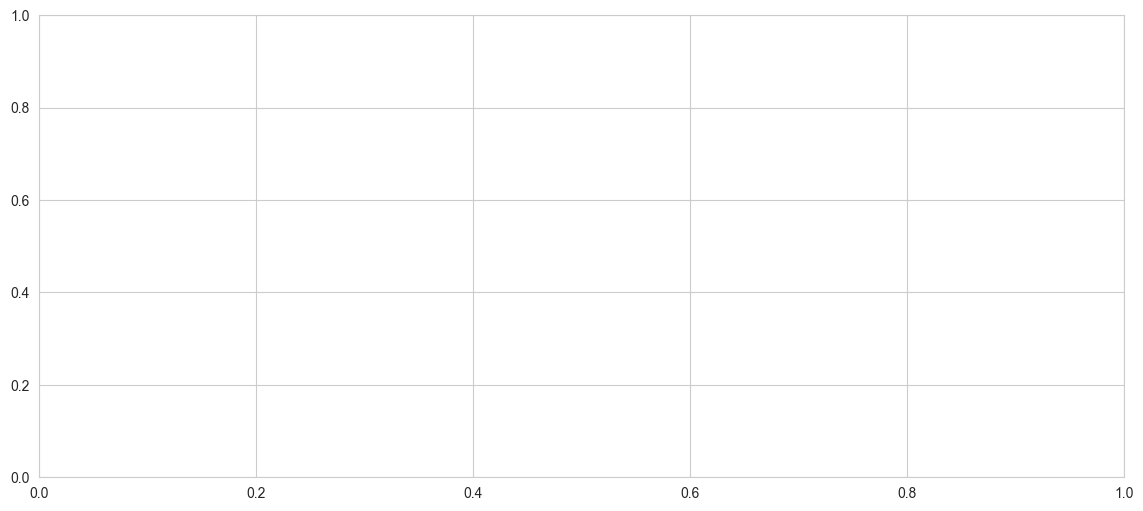

In [34]:
# Plot 1: Speedup comparison across all imputer types
fig, ax = plt.subplots(figsize=(14, 6))

imputer_types = ['Mean', 'Median', 'Constant (Numeric)', 'Categorical (Constant)']
x_pos = np.arange(len(dataset_sizes))
width = 0.15

for idx, imputer_type in enumerate(imputer_types):
    data = all_results[all_results['imputer_type'] == imputer_type]
    speedups = [data[data['dataset_size'] == size]['speedup_total'].mean() for size in dataset_sizes]
    
    ax.bar(x_pos + idx * width, speedups, width, label=imputer_type, alpha=0.8)

ax.set_xlabel('Dataset Size (rows)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Speedup (x)', fontsize=12, fontweight='bold')
ax.set_title('Gators vs Feature-engine: Average Speedup by Imputer Type', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos + width * 2)
ax.set_xticklabels([f'{size:,}' for size in dataset_sizes], rotation=45)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=1, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

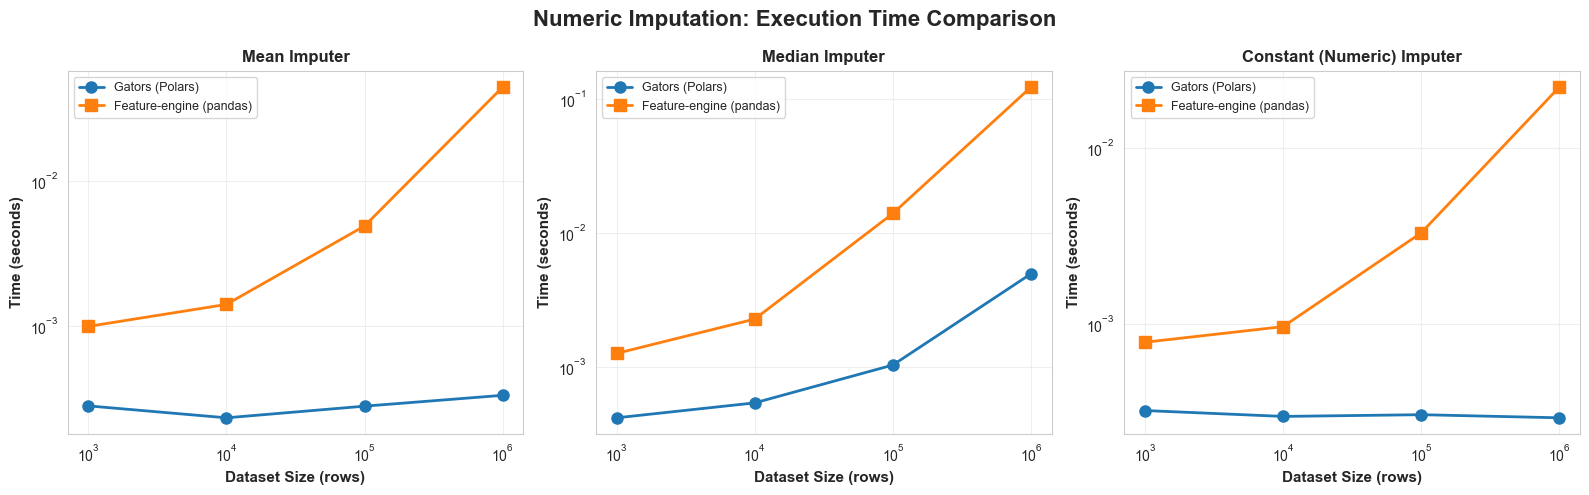

In [ ]:
# Plot 2: Execution time comparison for numeric imputers
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Numeric Imputation: Execution Time Comparison', fontsize=16, fontweight='bold')

numeric_imputer_types = ['Mean', 'Median', 'Constant (Numeric)']

for idx, imputer_type in enumerate(numeric_imputer_types):
    ax = axes[idx]
    
    data = all_results[all_results['imputer_type'] == imputer_type]
    
    # Aggregate by dataset size
    gators_times = [data[data['dataset_size'] == size]['gators_total'].mean() for size in dataset_sizes]
    fe_times = [data[data['dataset_size'] == size]['fe_total'].mean() for size in dataset_sizes]
    
    ax.plot(dataset_sizes, gators_times, marker='o', label='Gators (Polars)', linewidth=2, markersize=8)
    ax.plot(dataset_sizes, fe_times, marker='s', label='Feature-engine (pandas)', linewidth=2, markersize=8)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Dataset Size (rows)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title(f'{imputer_type} Imputer', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

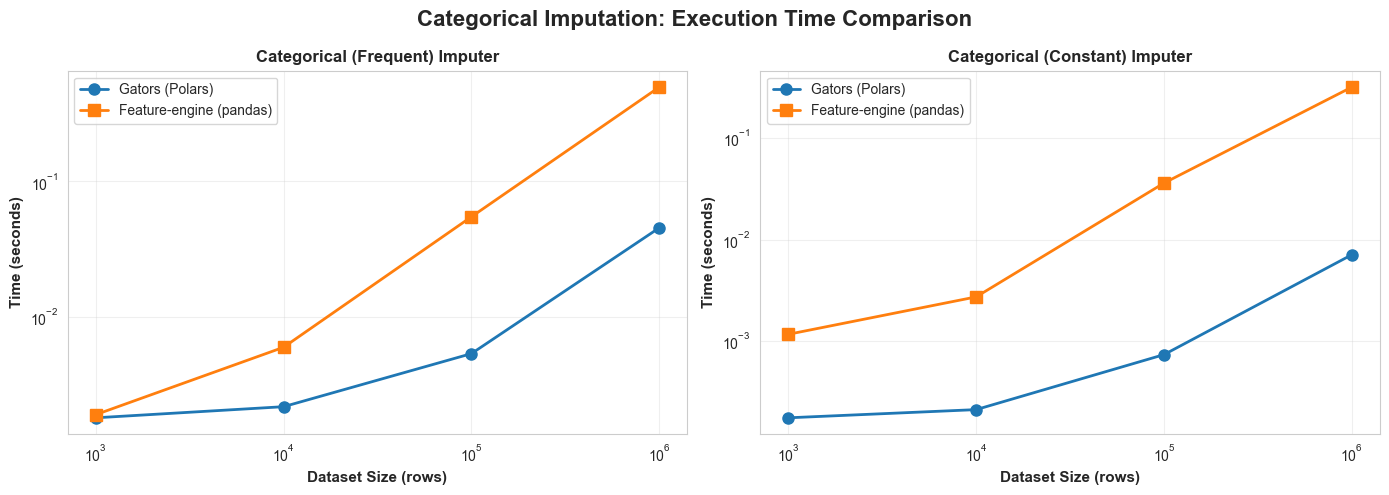

In [ ]:
# Plot 3: Execution time comparison for categorical imputer
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Categorical Imputation: Execution Time Comparison', fontsize=16, fontweight='bold')

imputer_type = 'Categorical (Constant)'
data = all_results[all_results['imputer_type'] == imputer_type]

# Aggregate by dataset size
gators_times = [data[data['dataset_size'] == size]['gators_total'].mean() for size in dataset_sizes]
fe_times = [data[data['dataset_size'] == size]['fe_total'].mean() for size in dataset_sizes]

ax.plot(dataset_sizes, gators_times, marker='o', label='Gators (Polars)', linewidth=2, markersize=8)
ax.plot(dataset_sizes, fe_times, marker='s', label='Feature-engine (pandas)', linewidth=2, markersize=8)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Dataset Size (rows)', fontsize=11, fontweight='bold')
ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
ax.set_title(f'{imputer_type} Imputer', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Plot 4: Heatmap of speedup by imputer type and dataset size
from matplotlib.colors import LogNorm


pivot = all_results.groupby(['imputer_type', 'dataset_size'])['speedup_total'].mean().reset_index()
pivot_table = pivot.pivot(index='imputer_type', columns='dataset_size', values='speedup_total')
pivot_table = pivot_table.reindex(imputer_types)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, fmt='.2f', 
            norm=LogNorm(vmin=pivot_table.min().min(), vmax=pivot_table.max().max()),
            cbar_kws={'label': 'Speedup (x)'}, ax=ax, linewidths=0.5, vmin=0)

ax.set_xlabel('Dataset Size (rows)', fontsize=12, fontweight='bold')
ax.set_ylabel('Imputer Type', fontsize=12, fontweight='bold')
ax.set_title('Gators vs Feature-engine: Speedup Heatmap', fontsize=14, fontweight='bold')
ax.set_xticklabels([f'{int(col):,}' for col in pivot_table.columns], rotation=45)

plt.tight_layout()
plt.show()

NameError: name 'all_results' is not defined

## Summary Statistics

In [ ]:
# Summary by imputer type
summary_by_imputer = all_results.groupby('imputer_type').agg({
    'gators_total': 'mean',
    'fe_total': 'mean',
    'speedup_total': 'mean'
}).round(4)

summary_by_imputer.columns = ['Avg Gators Time (s)', 'Avg Feature-engine Time (s)', 'Avg Speedup']
summary_by_imputer = summary_by_imputer.reindex(imputer_types)

print("\n" + "="*80)
print("SUMMARY BY IMPUTER TYPE")
print("="*80)
print(summary_by_imputer.to_string())

# Summary by dataset size
summary_by_size = all_results.groupby('dataset_size').agg({
    'gators_total': 'mean',
    'fe_total': 'mean',
    'speedup_total': 'mean'
}).round(4)

summary_by_size.columns = ['Avg Gators Time (s)', 'Avg Feature-engine Time (s)', 'Avg Speedup']
summary_by_size.index = [f'{size:,} rows' for size in summary_by_size.index]

print("\n" + "="*80)
print("SUMMARY BY DATASET SIZE")
print("="*80)
print(summary_by_size.to_string())
print("\n" + "="*80)


SUMMARY BY IMPUTER TYPE
                        Avg Gators Time (s)  Avg Feature-engine Time (s)  Avg Speedup
imputer_type                                                                         
Mean                                 0.0003                       0.0129      40.5440
Median                               0.0017                       0.0348      11.3612
Constant (Numeric)                   0.0003                       0.0068      22.7532
Categorical (Frequent)               0.0137                       0.1398       6.2516
Categorical (Constant)               0.0021                       0.0898      28.3655

SUMMARY BY DATASET SIZE
                Avg Gators Time (s)  Avg Feature-engine Time (s)  Avg Speedup
1,000 rows                   0.0006                       0.0012       3.3417
10,000 rows                  0.0007                       0.0027       5.8358
100,000 rows                 0.0015                       0.0226      20.2216
1,000,000 rows               0.0116 

## Key Findings

**Performance Observations**:

1. **Scalability**: Gators demonstrates increasing performance advantages as dataset size grows, leveraging Polars' multi-core parallel processing.

2. **Imputer Type**: All four imputation strategies show consistent speedup over feature-engine's pandas-based implementations.

3. **Numeric vs Categorical**: Both numeric and categorical imputation benefit from Gators' Polars architecture, with consistent performance gains across strategies.

4. **Production Value**: The speedup becomes more pronounced with larger datasets, making Gators ideal for production ML pipelines handling real-world data volumes.

**Conclusion**: Gators' Polars-based architecture provides significant performance improvements over feature-engine's pandas implementation, especially for large-scale data imputation tasks.